In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scipy.optimize as optimize

# import kwant
from scipy import linalg as la

# from alter_morph.kwant_utilities import (
#     crack_hamiltonian_for_contacts_kwant,
#     attach_leads_to_cracked,
# )

from scipy import linalg as la
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function

from tqdm import tqdm

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)

In [6]:
import sys, os

data_name = "data/full_phase_diagram_20_n_V0.pickle"

with open(data_name, "rb") as f:
    data = pickle.load(f)
with open("analysis/voronoi_20.pickle", "rb") as f:
    lattice = pickle.load(f)

In [7]:
fillings = data["filling"]
J_vals = data["J"]


avg_mags = np.zeros([len(fillings), len(J_vals)])
energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):

        current_data = data["params"][i, j]

        avg_mags[i, j] = np.mean(current_data["m"])

        ham = alt_hamiltonian(
            lattice,
            current_data["t1"],
            current_data["t2"],
            current_data["J"],
            current_data["U"],
            current_data["m"],
            current_data["n"],
        )

        energies[i, j] = la.eigvalsh(ham)


data["params"][0, 0].keys()

100%|██████████| 31/31 [04:39<00:00,  9.01s/it]


dict_keys(['t1', 't2', 'J', 'U', 'filling', 'theta_offset', 'm', 'n'])

In [ ]:
broadening = 0.01
dos_vals = np.zeros([len(fillings), len(J_vals)])
bond_diff_m = np.zeros([len(fillings), len(J_vals)])
bond_diff_n = np.zeros([len(fillings), len(J_vals)])

# size in MB

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):

        # dos at fermi level
        e = energies[i, j]
        fermi_energy = np.mean(e[int(filling * len(e)) - 1 : int(filling * len(e)) + 1])
        dos_vals[i, j] = dos_at_fermi(e, fermi_energy, broadening).real

        # difference in m on bonds
        m = data["params"][i, j]["m"]
        m_on_bonds = m[lattice.edges.indices]
        bond_diff_m[i, j] = np.abs(m_on_bonds[:, 0] - m_on_bonds[:, 1]).mean()

        # difference in n on bonds
        n = data["params"][i, j]["n"]
        n_on_bonds = n[lattice.edges.indices]
        bond_diff_n[i, j] = np.abs(n_on_bonds[:, 0] - n_on_bonds[:, 1]).mean()


J, FIL = np.meshgrid(J_vals, fillings)
print(FIL.shape, J.shape, avg_mags.shape, dos_vals.shape)

  0%|          | 0/31 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniforge/base/envs/physics/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/physics/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 31/31 [00:00<00:00, 459.09it/s]

(31, 41) (31, 41) (31, 41) (31, 41)


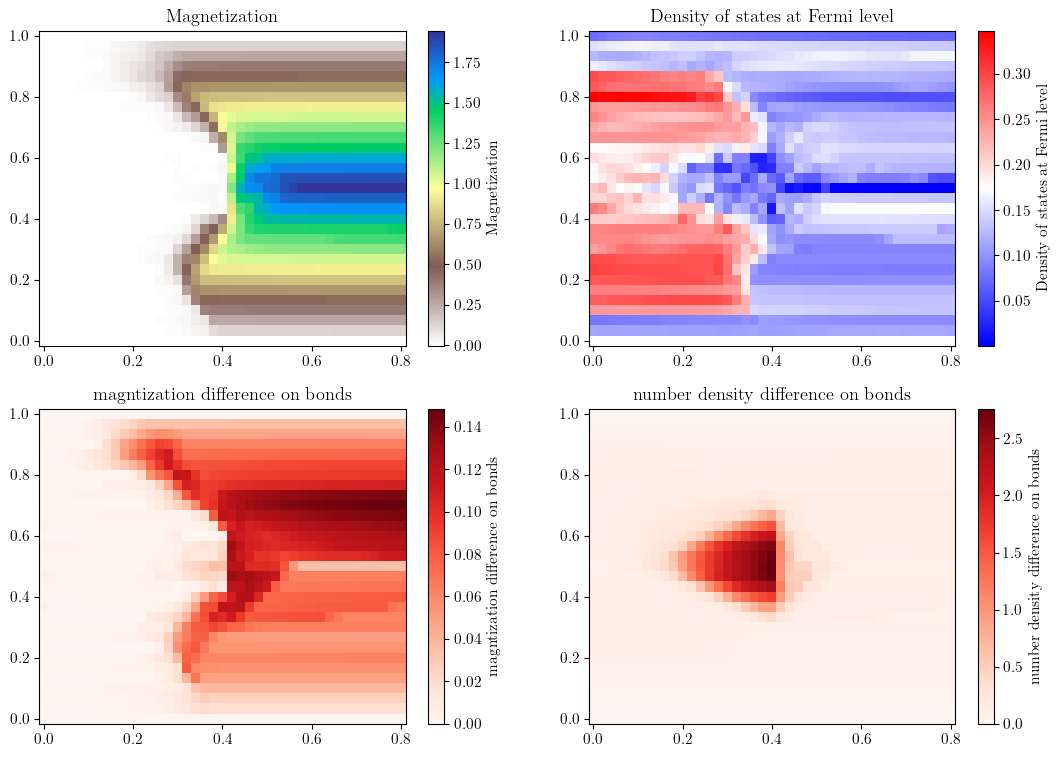

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax = ax.flatten()
# ax[0].pcolor(J, FIL, avg_mags, cmap="terrain_r")
ax[0].set_title("Magnetization")

# ax[1].pcolor(J, FIL, dos_vals, cmap="bwr")
ax[1].set_title("Density of states at Fermi level")

# ax[2].pcolor(J, FIL, bond_diff_m, cmap="Reds")
ax[2].set_title("magntization difference on bonds")

# ax[3].pcolor(J, FIL, bond_diff_n, cmap="Reds")
ax[3].set_title("number density difference on bonds")

# add colorbars
cbar = fig.colorbar(ax[0].pcolormesh(J, FIL, avg_mags, cmap="terrain_r"), ax=ax[0])
cbar.set_label("Magnetization")
cbar = fig.colorbar(ax[1].pcolormesh(J, FIL, dos_vals, cmap="bwr"), ax=ax[1])
cbar.set_label("Density of states at Fermi level")
cbar = fig.colorbar(ax[2].pcolormesh(J, FIL, bond_diff_m, cmap="Reds"), ax=ax[2])
cbar.set_label("magntization difference on bonds")
cbar = fig.colorbar(ax[3].pcolormesh(J, FIL, bond_diff_n, cmap="Reds"), ax=ax[3])
cbar.set_label("number density difference on bonds")


plt.show()